# Scikit-learn for Regression Models: regression four ways

In [68]:
# Import required library

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

pumpkins = pd.read_csv('../data/US-pumpkins.csv')

pumpkins.head()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [69]:
#Data standarization

pumpkins = pumpkins[pumpkins['Package'].str.contains('bushel', case=True, regex=True)]

columns_to_select = ['Package', 'Variety', 'City Name', 'Low Price', 'High Price', 'Date']
pumpkins = pumpkins.loc[:, columns_to_select]

price = (pumpkins['Low Price'] + pumpkins['High Price']) / 2

month = pd.DatetimeIndex(pumpkins['Date']).month
day_of_year = pd.to_datetime(pumpkins['Date']).apply(lambda dt: (dt - datetime(dt.year, 1, 1)).days)

new_pumpkins = pd.DataFrame({
    'Month': month, 
    'DayOfYear' : day_of_year, 
    'Variety': pumpkins['Variety'], 
    'City': pumpkins['City Name'], 
    'Package': pumpkins['Package'], 
    'Low Price': pumpkins['Low Price'],
    'High Price': pumpkins['High Price'], 
    'Price': price
    })

new_pumpkins.loc[new_pumpkins['Package'].str.contains('1 1/9'), 'Price'] = price/1.1
new_pumpkins.loc[new_pumpkins['Package'].str.contains('1/2'), 'Price'] = price*2

new_pumpkins.head()

/tmp/ipykernel_73991/2822012209.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  day_of_year = pd.to_datetime(pumpkins['Date']).apply(lambda dt: (dt - datetime(dt.year, 1, 1)).days)


,Month,DayOfYear,Variety,City,Package,Low Price,High Price,Price
70,9,267,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,15.0,15.0,13.636364
71,9,267,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,18.0,18.0,16.363636
72,10,274,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,18.0,18.0,16.363636
73,10,274,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,17.0,17.0,15.454545
74,10,281,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,15.0,15.0,13.636364


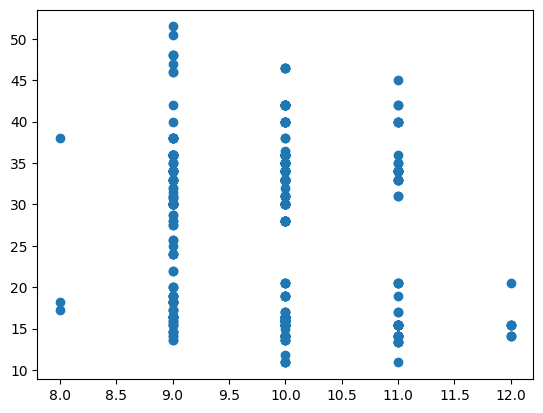

In [70]:
import matplotlib.pyplot as plt
plt.scatter('Month','Price',data=new_pumpkins)

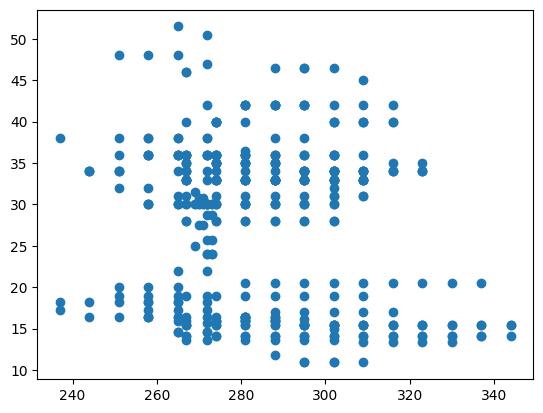

In [71]:
plt.scatter('DayOfYear','Price',data=new_pumpkins)

In [72]:
# See the correlation

print(new_pumpkins['Month'].corr(new_pumpkins['Price']))
print(new_pumpkins['DayOfYear'].corr(new_pumpkins['Price']))

-0.14878293554077526
-0.1667332249274541


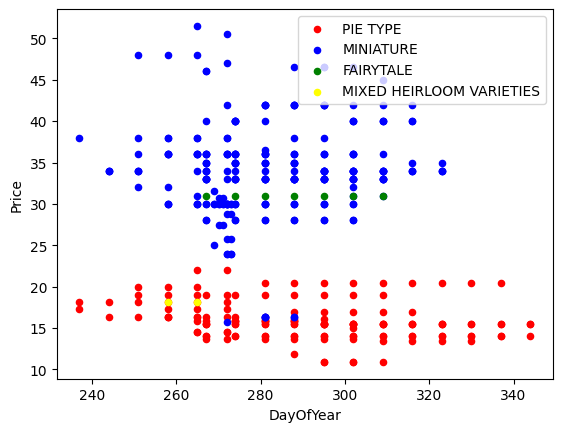

In [73]:
# Plot each pumpkin category using a different color to confirm there are different clusters of prices corresponding to different pumpkin varieties.

ax=None
colors = ['red', 'blue', 'green', 'yellow']
for i, var in enumerate(new_pumpkins['Variety'].unique()):
    df = new_pumpkins[new_pumpkins['Variety']==var]
    ax = df.plot.scatter('DayOfYear', 'Price', ax=ax, color=colors[i], label=var)

<Axes: xlabel='Variety'>

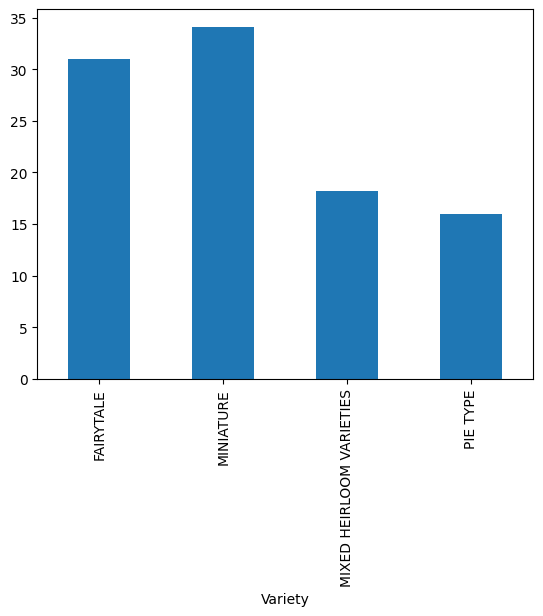

In [74]:
# Variety has more effect on the overall price than the actual selling date.

new_pumpkins.groupby('Variety')['Price'].mean().plot(kind='bar')

<Axes: xlabel='DayOfYear', ylabel='Price'>

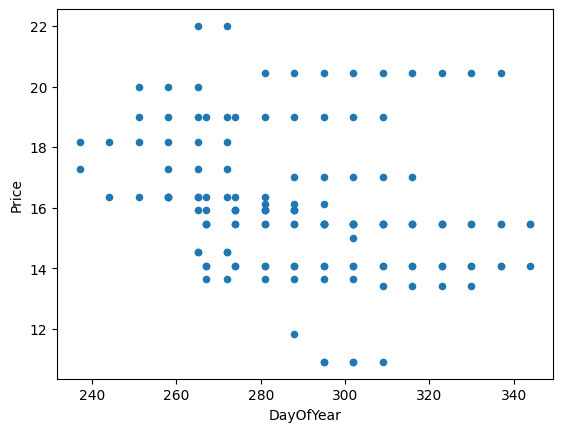

In [75]:
# See what date effects on the price by focuse for the moment only on one variety.

pie_pumpkins = new_pumpkins[new_pumpkins['Variety']=="PIE TYPE"]
pie_pumpkins.plot.scatter('DayOfYear', 'Price')

In [76]:
# The correlation of price and day of year more higher on one of the variety type than for the whole types.

print(pie_pumpkins['Price'].corr(pie_pumpkins['DayOfYear']))

-0.2669192282197318


In [77]:
# Getting rid of all empty cells.

pie_pumpkins.dropna(inplace=True)
pie_pumpkins.info

<bound method DataFrame.info of       Month  DayOfYear   Variety          City               Package  \
70        9        267  PIE TYPE     BALTIMORE  1 1/9 bushel cartons   
71        9        267  PIE TYPE     BALTIMORE  1 1/9 bushel cartons   
72       10        274  PIE TYPE     BALTIMORE  1 1/9 bushel cartons   
73       10        274  PIE TYPE     BALTIMORE  1 1/9 bushel cartons   
74       10        281  PIE TYPE     BALTIMORE  1 1/9 bushel cartons   
...     ...        ...       ...           ...                   ...   
1626     10        295  PIE TYPE  PHILADELPHIA  1 1/9 bushel cartons   
1627     10        302  PIE TYPE  PHILADELPHIA  1 1/9 bushel cartons   
1628      8        237  PIE TYPE  PHILADELPHIA  1 1/9 bushel cartons   
1629      9        258  PIE TYPE  PHILADELPHIA  1 1/9 bushel cartons   
1630      9        265  PIE TYPE  PHILADELPHIA  1 1/9 bushel cartons   

      Low Price  High Price      Price  
70         15.0        15.0  13.636364  
71         18.0      

### Simple Linear Regression

In [78]:
# Import required library

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [79]:
# Separating features and label.

X = new_pumpkins['DayOfYear'].to_numpy().reshape(-1, 1)
y = new_pumpkins['Price']

In [80]:
# Split data into train and test datasets.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [ ]:
# Define linear regression model and fit to data

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

In [82]:
# Predict prices on a test datasets using mean square error (MSE) metrics.

pred = lin_reg.predict(X_test)
mse = np.sqrt(mean_squared_error(y_test, pred))
print(f'Mean error: {mse:3.3} ({mse/np.mean(pred)*100:3.3}%)')

Mean error: 10.6 (37.9%)


In [83]:
# Coefficient of determination.

score = lin_reg.score(X_train,y_train)
print('Model determination: ', score)

Model determination:  0.021940482889036717


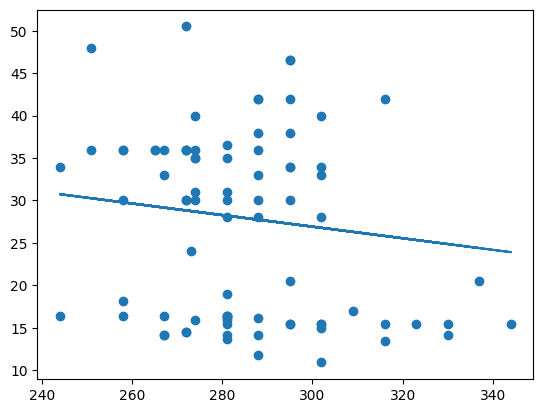

In [84]:
# Plot the test data together with the regression line to better see how regression works

plt.scatter(X_test, y_test)
plt.plot(X_test, pred)

### Polinomial Regression

In [ ]:
# Create a polynomial regression model (degree 2)

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

pipeline = make_pipeline(PolynomialFeatures(2), LinearRegression())

pipeline.fit(X_train, y_train)

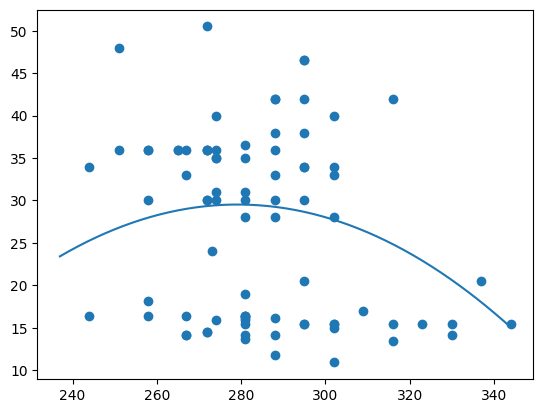

In [86]:
# Visualizing curve

X_range = np.linspace(X.min(), X.max(), 200).reshape(-1,1)
y_range = pipeline.predict(X_range)

plt.scatter(X_test, y_test)
plt.plot(X_range, y_range)
plt.show()

### Categorical Features

In [87]:
# One-hot encode the variety feature

pd.get_dummies(new_pumpkins['Variety'])

,FAIRYTALE,MINIATURE,MIXED HEIRLOOM VARIETIES,PIE TYPE
70,False,False,False,True
71,False,False,False,True
72,False,False,False,True
73,False,False,False,True
74,False,False,False,True
...,...,...,...,...
1738,False,True,False,False
1739,False,True,False,False
1740,False,True,False,False
1741,False,True,False,False


In [88]:
# Initialize X and y data

X = pd.get_dummies(new_pumpkins['Variety'])
y = new_pumpkins['Price']

In [89]:
# Using join to get one large array of features

X = pd.get_dummies(new_pumpkins['Variety']) \
        .join(new_pumpkins['Month']) \
        .join(pd.get_dummies(new_pumpkins['City'])) \
        .join(pd.get_dummies(new_pumpkins['Package']))
y = new_pumpkins['Price']

### Put all together

In [112]:
# Combining (one-hot categorical + numeric) with polynomial regression

X = pd.get_dummies(new_pumpkins['Variety']) \
        .join(new_pumpkins['Month']) \
        .join(pd.get_dummies(new_pumpkins['City'])) \
        .join(pd.get_dummies(new_pumpkins['Package']))
y = new_pumpkins['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

pipeline = make_pipeline(PolynomialFeatures(2), LinearRegression())
pipeline.fit(X_train, y_train)

pred = pipeline.predict(X_test)

mse = np.sqrt(mean_squared_error(y_test, pred))
print(f'Mean error: {mse:3.3} ({mse/np.mean(pred)*100:3.3}%)')

score = pipeline.score(X_train,y_train)
print('Model determination: ', score)

Mean error: 2.23 (8.28%)
Model determination:  0.9653029999448537


### Assignment

In this lesson you were shown how to build a model using both Linear and Polynomial Regression. Using this knowledge, find a dataset or use one of Scikit-learn's built-in sets to build a fresh model. Explain in your notebook why you chose the technique you did, and demonstrate your model's accuracy. If it is not accurate, explain why.

In [91]:
import seaborn as sns

diamonds = sns.load_dataset('diamonds')

print(diamonds.head())

   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75


In [125]:
print(diamonds['carat'].corr(diamonds['price']))
print(diamonds['depth'].corr(diamonds['price']))
print(diamonds['table'].corr(diamonds['price']), end='\n\n')
print(diamonds['x'].corr(diamonds['carat']))
print(diamonds['y'].corr(diamonds['carat']))
print(diamonds['z'].corr(diamonds['carat']))

0.9215913011934773
-0.010647404584142987
0.12713390212174194

0.9750942267264209
0.9517221990129812
0.9533873805614188


Mean error: 1.58e+03 (40.0%)
Model determination:  0.8492599516300134


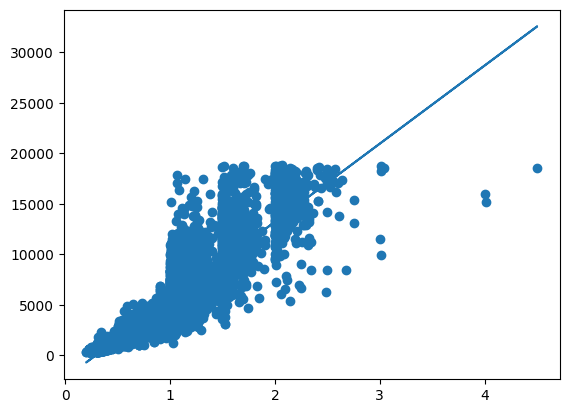

In [106]:
X = diamonds['carat'].to_numpy().reshape(-1, 1)
y = diamonds['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

pred = lin_reg.predict(X_test)

mse = np.sqrt(mean_squared_error(y_test, pred))
print(f'Mean error: {mse:3.3} ({mse/np.mean(pred)*100:3.3}%)')

score = lin_reg.score(X_train,y_train)
print('Model determination: ', score)

plt.scatter(X_test, y_test)
plt.plot(X_test, pred)

Mean error: 1.57e+03 (39.9%)
Model determination:  0.8510740998254107


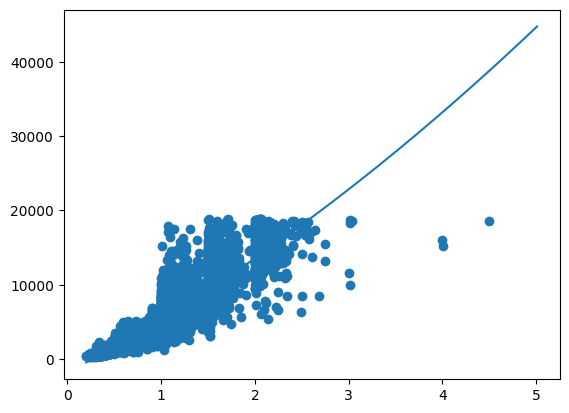

In [99]:
X = diamonds['carat'].to_numpy().reshape(-1, 1)
y = diamonds['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67)

pipeline = make_pipeline(PolynomialFeatures(2), LinearRegression())
pipeline.fit(X_train, y_train)

pred = pipeline.predict(X_test)

mse = np.sqrt(mean_squared_error(y_test, pred))
print(f'Mean error: {mse:3.3} ({mse/np.mean(pred)*100:3.3}%)')

score = pipeline.score(X_train,y_train)
print('Model determination: ', score)


X_range = np.linspace(X.min(), X.max(), 200).reshape(-1,1)
y_range = pipeline.predict(X_range)

plt.scatter(X_test, y_test)
plt.plot(X_range, y_range)
plt.show()

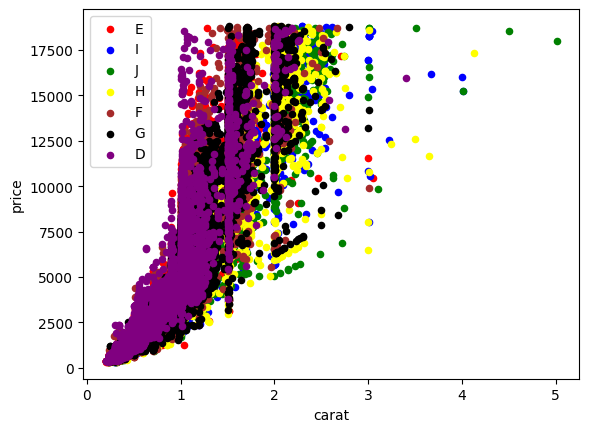

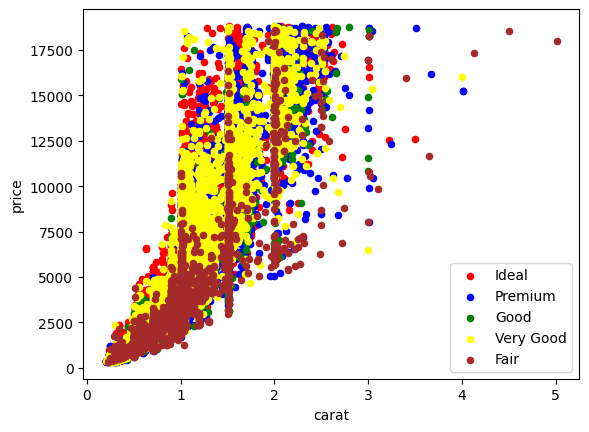

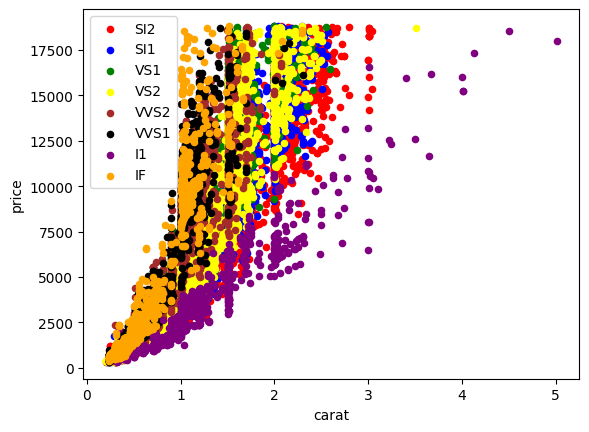

In [102]:
ax=None
colors = ['red', 'blue', 'green', 'yellow', 'brown', 'black', 'purple']
for i, var in enumerate(diamonds['color'].unique()):
    df = diamonds[diamonds['color']==var]
    ax = df.plot.scatter('carat', 'price', ax=ax, color=colors[i], label=var)

ax=None
colors = ['red', 'blue', 'green', 'yellow', 'brown']
for i, var in enumerate(diamonds['cut'].unique()):
    df = diamonds[diamonds['cut']==var]
    ax = df.plot.scatter('carat', 'price', ax=ax, color=colors[i], label=var)

ax=None
colors = ['red', 'blue', 'green', 'yellow', 'brown', 'black', 'purple', 'orange']
for i, var in enumerate(diamonds['clarity'].unique()):
    df = diamonds[diamonds['clarity']==var]
    ax = df.plot.scatter('carat', 'price', ax=ax, color=colors[i], label=var)

In [124]:
X= pd.get_dummies(diamonds['color']) \
        .join(diamonds['carat']) \
        .join(diamonds['x']) \
        .join(diamonds['y']) \
        .join(diamonds['z']) \
        .join(pd.get_dummies(diamonds['cut'])) \
        .join(pd.get_dummies(diamonds['clarity']))
y = diamonds['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67)

pipeline = make_pipeline(PolynomialFeatures(2), LinearRegression())
pipeline.fit(X_train, y_train)

pred = pipeline.predict(X_test)

mse = np.sqrt(mean_squared_error(y_test, pred))
print(f'Mean error: {mse:3.3} ({mse/np.mean(pred)*100:3.3}%)')

score = pipeline.score(X_train,y_train)
print('Model determination: ', score)

Mean error: 6.84e+02 (17.2%)
Model determination:  0.9711133054441689


Explanation:

In this assignment, I used the Diamonds dataset to test machine learning models. First, I examined the correlation between numerical features and removed redundant features such as x, y, and z, which appeared to be correlated with carats, as well as removing irrelevant noise. Then, I tried simple linear regression using only the ‘carat’ feature, as it had the highest correlation, followed by polynomial regression, which gave slightly more accurate results. After visualizing the categorical variables, I noticed a clear pattern that could further improve the model. Therefore, I combined the numerical features with one-hot encoded categorical variables, which resulted in a much more precise and accurate final model. However, I understand that in real-world scenarios, it is better to test models using small data samples to speed up the process and save computational resources, although I have not implemented that specific optimization in this lesson.